In [459]:
import yfinance as yf
import numpy as np
import pandas as pd
import pandas_datareader as web
import matplotlib.pyplot as plt
import statsmodels.api as sm
import datetime

In [485]:
def get_date(start_date, end_date=None):
    '''
    fetches dates for ff3 and stock data.
    deploy this function to reduce complexity/potential misalignment of data
    Formatting for dates: "YYYY-MM-DD"
    '''
    if end_date == None:
        end_date = datetime.datetime.now()
    else:
        end_date = pd.to_datetime(end_date)

    start_date = pd.to_datetime(start_date)

    return start_date, end_date

In [486]:
def fetch_ff3_data(start_date, end_date="None"):
    '''
    Fetching FF3 Factor data for a given timeframe using Ken French API
    '''
    start_date, end_date = get_date(start_date, end_date)
    ff_data = web.DataReader('F-F_Research_Data_Factors', 'famafrench', start=start_date, end=end_date)
    del(ff_data["DESCR"], ff_data[1])
    ff_data = pd.DataFrame(ff_data[0]) / 100
    return(ff_data)

In [484]:
def fetch_stock(stock_ticker, start_date, end_date="None"):
    '''
    fetching daily stock returns, which are then converted to monthly stock data in order to match ff3 data
    '''
    start_date, end_date = get_date(start_date, end_date)
    resample_logic ={"Close":"last"}

    daily = yf.Ticker(stock_ticker).history(start=start_date, end=end_date)
        
    monthly = daily.resample("M").agg(resample_logic).to_period("M")
    
    monthly_returns = monthly.pct_change().dropna()
    return monthly_returns

In [488]:
def prep_stocks(ticker_list, start_date, end_date):
    '''
    Function that creates dataframe that summarises the returns for a list of provided stock tickers
    '''
    new_df = pd.concat((fetch_stock(i, start_date, end_date) for i in ticker_list), axis = 1)
    new_df.columns = ticker_list
    return new_df

In [475]:
def reg_prep(stock_df, ff3_data):
    '''
    Creating a function that cleans and prepares our stock data for regression
    '''
    joined_df = stock_df.join(ff3_data, how="inner")

    stock_cols = stock_df.columns
    ff3_cols = ff3_data.columns[:-1]
    
    joined_df[stock_cols] = joined_df[stock_cols].sub(joined_df["RF"],axis = 0)
    
    Y = joined_df[stock_cols]
    X = sm.add_constant(joined_df[ff3_cols])
    return X, Y

In [473]:
def regress(X, Y):
    '''
    Creates dictionary that stores the regression summaries for every stock contained in Returns Y
    Prints Summary statistics for regression.
    '''
    regression_data = {}
    for i in Y.columns:
        model = sm.OLS(Y[i], X)
        results = model.fit()
        regression_data[i] = results
    [print(regression_data[j].summary()) for j in regression_data]
    return regression_data

In [480]:
def stock_plot(Y, title="Stock Alpha", xlabel="Date", ylabel="Returns", grid=True):
    '''
    plots any dataframe of stocks
    x-axis default: date (PeriodIndex: "YYYY-MM"
    y-axis default: Stock Alpha (in percent)
    '''

    if not isinstance(title, str):
        raise TypeError(f"Expected String input, instead received {type(title)}")
    if not isinstance(xlabel, str):
        raise TypeError(f"Expected String input, instead received {type(xlabel)}")
    if not isinstance(ylabel, str):
        raise TypeError(f"Expected String input, instead received {type(ylabel)}")
    if not isinstance(grid, bool):
        raise TypeError(f"Expected True or False, instead received {type(grid)}")
    
    plt.figure(figsize=(10,6))
    Y.plot()
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(grid)
    plt.show

In [460]:
# TESTING BLOCK:

In [479]:
# 1. get_date, 2. fetch_ff3_data, 3. fetch_stock, 4. prep_stocks, 5. reg_prep, 6. regress
tickers = ["AAPL", "MSFT", "GOOGL", "AMZN", "TSLA"]

start, end = get_date("2020-12-31")
ff3 = fetch_ff3_data(start, end)
stock_data = prep_stocks(tickers, start, end) # if fetch stocks, theres an error I think if used a list
X, Y = reg_prep(stock_data, ff3)
regress(X=X, Y=Y)

/var/folders/lg/8378lyw55rqdlc0qt63jgcy00000gn/T/ipykernel_52173/1643140481.py:5: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff_data = web.DataReader('F-F_Research_Data_Factors', 'famafrench', start=start_date, end=end_date)
/var/folders/lg/8378lyw55rqdlc0qt63jgcy00000gn/T/ipykernel_52173/1643140481.py:5: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff_data = web.DataReader('F-F_Research_Data_Factors', 'famafrench', start=start_date, end=end_date)
/var/folders/lg/8378lyw55rqdlc0qt63jgcy00000gn/T/ipykernel_52173/1187047710.py:10: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = daily.resample("M").agg(resample_logic).

                            OLS Regression Results                            
Dep. Variable:                   AAPL   R-squared:                       0.478
Model:                            OLS   Adj. R-squared:                  0.449
Method:                 Least Squares   F-statistic:                     16.20
Date:                Thu, 20 Nov 2025   Prob (F-statistic):           1.35e-07
Time:                        22:42:28   Log-Likelihood:                 88.101
No. Observations:                  57   AIC:                            -168.2
Df Residuals:                      53   BIC:                            -160.0
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0051      0.008      0.680      0.4

/var/folders/lg/8378lyw55rqdlc0qt63jgcy00000gn/T/ipykernel_52173/1187047710.py:10: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = daily.resample("M").agg(resample_logic).to_period("M")
/var/folders/lg/8378lyw55rqdlc0qt63jgcy00000gn/T/ipykernel_52173/1187047710.py:10: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly = daily.resample("M").agg(resample_logic).to_period("M")


{'AAPL': <statsmodels.regression.linear_model.RegressionResultsWrapper at 0x1439a1250>,
 'MSFT': <statsmodels.regression.linear_model.RegressionResultsWrapper at 0x1438ef5f0>,
 'GOOGL': <statsmodels.regression.linear_model.RegressionResultsWrapper at 0x143a68290>,
 'AMZN': <statsmodels.regression.linear_model.RegressionResultsWrapper at 0x143a689b0>,
 'TSLA': <statsmodels.regression.linear_model.RegressionResultsWrapper at 0x143b36f90>}

In [451]:
regress(Y,X)

                                 OLS Regression Results                                
Dep. Variable:                   AAPL   R-squared (uncentered):                   0.488
Model:                            OLS   Adj. R-squared (uncentered):              0.460
Method:                 Least Squares   F-statistic:                              17.16
Date:                Thu, 20 Nov 2025   Prob (F-statistic):                    5.96e-08
Time:                        22:28:56   Log-Likelihood:                          87.853
No. Observations:                  57   AIC:                                     -169.7
Df Residuals:                      54   BIC:                                     -163.6
Df Model:                           3                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

{'AAPL': <statsmodels.regression.linear_model.RegressionResultsWrapper at 0x143cb0170>,
 'MSFT': <statsmodels.regression.linear_model.RegressionResultsWrapper at 0x143cb2150>,
 'GOOGL': <statsmodels.regression.linear_model.RegressionResultsWrapper at 0x143cb09b0>,
 'AMZN': <statsmodels.regression.linear_model.RegressionResultsWrapper at 0x143cb2270>,
 'TSLA': <statsmodels.regression.linear_model.RegressionResultsWrapper at 0x143cb1e50>}

In [364]:
tickers = ["AAPL", "MSFT", "GOOGL", "AMZN", "TSLA"]

start, end = get_date("2020-12-31")
ff3 = fetch_ff3_data(start, end)
stocks_df = prep_stocks(tickers, start, end)
X, Y = reg_prep(stocks_df, ff3)

print(f" {X} \n\n {Y}")

/var/folders/lg/8378lyw55rqdlc0qt63jgcy00000gn/T/ipykernel_52173/4071123344.py:6: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff_data = web.DataReader('F-F_Research_Data_Factors', 'famafrench', start=start_date, end=end_date)
/var/folders/lg/8378lyw55rqdlc0qt63jgcy00000gn/T/ipykernel_52173/4071123344.py:6: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff_data = web.DataReader('F-F_Research_Data_Factors', 'famafrench', start=start_date, end=end_date)
/var/folders/lg/8378lyw55rqdlc0qt63jgcy00000gn/T/ipykernel_52173/1187047710.py:10: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = daily.resample("M").agg(resample_logic).

          Mkt-RF     SMB     HML
Date                           
2021-01 -0.0007  0.0714  0.0322
2021-02  0.0281  0.0202  0.0720
2021-03  0.0316 -0.0233  0.0735
2021-04  0.0495 -0.0319 -0.0102
2021-05  0.0030 -0.0020  0.0704
2021-06  0.0274  0.0170 -0.0786
2021-07  0.0134 -0.0393 -0.0179
2021-08  0.0294 -0.0032 -0.0023
2021-09 -0.0440  0.0066  0.0512
2021-10  0.0663 -0.0227 -0.0053
2021-11 -0.0158 -0.0131 -0.0037
2021-12  0.0323 -0.0163  0.0326
2022-01 -0.0616 -0.0593  0.1286
2022-02 -0.0228  0.0216  0.0306
2022-03  0.0308 -0.0155 -0.0190
2022-04 -0.0941 -0.0135  0.0618
2022-05 -0.0034 -0.0184  0.0844
2022-06 -0.0840  0.0207 -0.0600
2022-07  0.0957  0.0284 -0.0415
2022-08 -0.0377  0.0141  0.0018
2022-09 -0.0934 -0.0076  0.0003
2022-10  0.0785  0.0001  0.0797
2022-11  0.0465 -0.0357  0.0148
2022-12 -0.0638 -0.0076  0.0134
2023-01  0.0661  0.0501 -0.0394
2023-02 -0.0257  0.0105 -0.0080
2023-03  0.0248 -0.0548 -0.0905
2023-04  0.0062 -0.0337 -0.0012
2023-05  0.0034  0.0160 -0.0779
2023-06

/var/folders/lg/8378lyw55rqdlc0qt63jgcy00000gn/T/ipykernel_52173/1187047710.py:10: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = daily.resample("M").agg(resample_logic).to_period("M")
/var/folders/lg/8378lyw55rqdlc0qt63jgcy00000gn/T/ipykernel_52173/1187047710.py:10: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly = daily.resample("M").agg(resample_logic).to_period("M")


/var/folders/lg/8378lyw55rqdlc0qt63jgcy00000gn/T/ipykernel_52173/1187047710.py:10: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = daily.resample("M").agg(resample_logic).to_period("M")
/var/folders/lg/8378lyw55rqdlc0qt63jgcy00000gn/T/ipykernel_52173/1187047710.py:10: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly = daily.resample("M").agg(resample_logic).to_period("M")


<Figure size 1000x600 with 0 Axes>

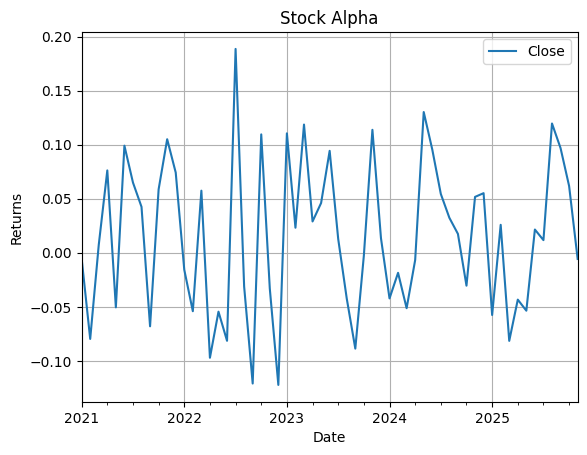

<Figure size 1000x600 with 0 Axes>

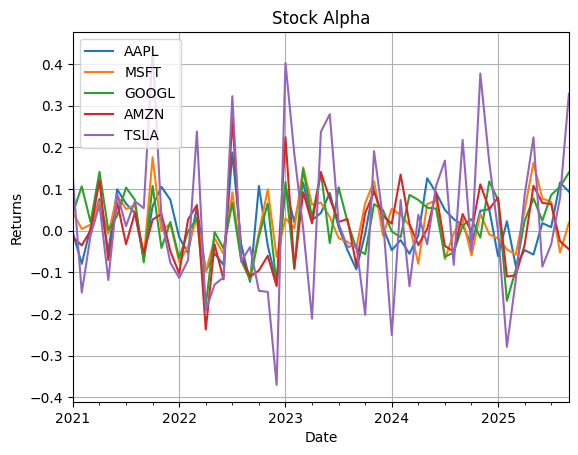

In [405]:
B = fetch_stock("AAPL", start, end)

stock_plot(B)
stock_plot(Y)

In [258]:
def get_date(start_date, end_date=None):
    '''
    fetches dates for ff3 and stock data.
    deploy this function to reduce complexity/potential misalignment of data
    Formatting for dates: "YYYY-MM-DD"
    '''
    if end_date == None:
        end_date = datetime.datetime.now()
    else:
        pd.to_datetime(end_date)

    start_date = pd.to_datetime(start_date)

    return start_date, end_date

In [262]:
def fetch_stock(stock_ticker, start_date, end_date):
    '''
    fetching daily stock returns, which are then converted to monthly stock data in order to match ff3 data
    '''

    resample_logic ={"Close":"last"}

    daily = yf.Ticker(stock_ticker).history(start=start_date, end=end_date)
        
    monthly = daily.resample("M").agg(resample_logic).to_period("M")
    
    monthly_returns = monthly.pct_change()
    return monthly_returns

In [351]:
# Function for plotting Data

def stock_plot(stock_arr, plt_title="", labelx="Date (YYYY-MM)", labely="", grid_stat=True):

    if not isinstance(plt_title, str):
        raise TypeError(f"Expected String input, instead received {type(title)}")
    if not isinstance(labelx, str):
        raise TypeError(f"Expected String input, instead received {type(labelx)}")
    if not isinstance(labely, str):
        raise TypeError(f"Expected String input, instead received {type(labely)}")
    if not isinstance(grid_stat, bool):
        raise TypeError(f"Expected True or False, instead received {type(grid_stat)}")

    # x_axis = np.linspace(start=arr.index.year[1], stop=arr.index.year[-1], num= arr.index.year.size)
    
    plt.figure(figsize=(10, 6))
    arr.plot()
    plt.title(plt_title)
    plt.ylabel(labely)
    plt.xlabel(labelx)
    plt.grid(grid_stat)
    plt.show()



In [247]:
def fetch_data(stock_ticker, start_date, end_date):

    #fetching stock data

    resample_logic ={"Close":"last"}

    daily = yf.Ticker(stock_ticker).history(start=start_date, end=end_date)
        
    monthly = daily.resample("M").agg(resample_logic).to_period("M")
    
    monthly_returns = monthly.pct_change()

    #fetching ff3 data for according period

    ff_data = web.DataReader('F-F_Research_Data_Factors', 'famafrench', start=start_date, end=end_date)
    del(ff_data["DESCR"], ff_data[1])
    ff_data = pd.DataFrame(ff_data[0]) / 100

    #combine both dataframes, matching indices

    combined_df = monthly_returns.join(ff_data, how="inner").dropna()
    return(combined_df)

In [248]:
ff3 = fetch_ff3_data("2018-01-01", "2024-12-31")
apple = fetch_data("AAPL", "2017-12-31", "2024-12-31")

apple

/var/folders/lg/8378lyw55rqdlc0qt63jgcy00000gn/T/ipykernel_52173/3360809208.py:3: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff_data = web.DataReader('F-F_Research_Data_Factors', 'famafrench', start=start_date, end=end_date)
/var/folders/lg/8378lyw55rqdlc0qt63jgcy00000gn/T/ipykernel_52173/3360809208.py:3: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff_data = web.DataReader('F-F_Research_Data_Factors', 'famafrench', start=start_date, end=end_date)
/var/folders/lg/8378lyw55rqdlc0qt63jgcy00000gn/T/ipykernel_52173/4159454068.py:9: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = daily.resample("M").agg(resample_logic).t

,Close,Mkt-RF,SMB,HML,RF
Date,,,,,
2018-02,0.068185,-0.0364,0.0027,-0.0110,0.0011
2018-03,-0.058051,-0.0235,0.0405,-0.0021,0.0012
2018-04,-0.015020,0.0027,0.0109,0.0053,0.0014
2018-05,0.135124,0.0266,0.0524,-0.0314,0.0014
2018-06,-0.009418,0.0049,0.0111,-0.0233,0.0014
...,...,...,...,...,...
2024-08,0.032354,0.0160,-0.0349,-0.0110,0.0048
2024-09,0.017467,0.0172,-0.0013,-0.0277,0.0040
2024-10,-0.030429,-0.0100,-0.0099,0.0086,0.0039


In [151]:
Y, X = prep_data(apple, ff3)


TypeError: unsupported Type PeriodIndex

In [107]:
reg_df = pd.concat([apple, ff3], axis = 1)
print(reg_df)

                           Relative Returns  Mkt-RF     SMB     HML      RF
Date                                                                       
2018-02-28 00:00:00-05:00          0.068185     NaN     NaN     NaN     NaN
2018-03-31 00:00:00-04:00         -0.058051     NaN     NaN     NaN     NaN
2018-04-30 00:00:00-04:00         -0.015020     NaN     NaN     NaN     NaN
2018-05-31 00:00:00-04:00          0.135124     NaN     NaN     NaN     NaN
2018-06-30 00:00:00-04:00         -0.009418     NaN     NaN     NaN     NaN
...                                     ...     ...     ...     ...     ...
2024-08                                 NaN  0.0160 -0.0349 -0.0110  0.0048
2024-09                                 NaN  0.0172 -0.0013 -0.0277  0.0040
2024-10                                 NaN -0.0100 -0.0099  0.0086  0.0039
2024-11                                 NaN  0.0649  0.0446  0.0015  0.0040
2024-12                                 NaN -0.0317 -0.0271 -0.0300  0.0037

[167 rows x

In [97]:
    reg_df = pd.merge(stock_arr, ff3_data, left_index=True, right_index=True, how='inner')

    reg_df["Excess_Returns"] = reg_df["Relative Returns"] - reg_df["RF"]

    Y = reg_df["Excess_Returns"]

    X = reg_df[['Mkt-RF', 'SMB', 'HML']]

Empty DataFrame
Columns: [Relative Returns, Mkt-RF, SMB, HML, RF]
Index: []


In [345]:
stock_plot(ff3, "Excess_Returns", "Date", "Excess Returns", True)

NameError: name 'arr' is not defined

<Figure size 1000x600 with 0 Axes>

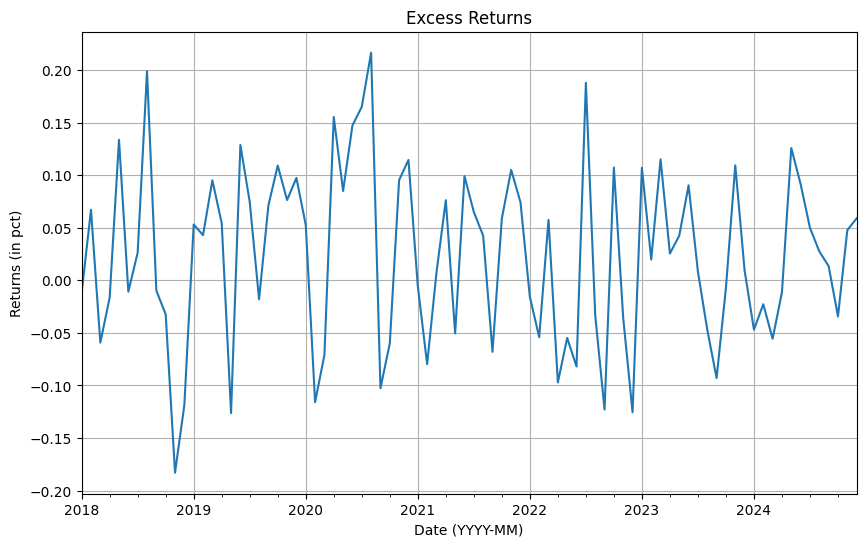

In [74]:
stock_plot(arr=apple_er, plt_title="Excess Returns", labely="Returns (in pct)")

In [77]:
print(OLS_Regression(stock_data, regressors))

ValueError: zero-size array to reduction operation maximum which has no identity